# Applied Machine Learning: In-class Exercise 06-1

## Goal

Our goal for this exercise sheet is to benchmark models in multiple scenarios, using hypothesis tests as an additional diagnostic tool to make the benchmark more rigorous.

### Required packages

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(2025)
# sklearn will be loaded later in the notebook

## 1 Two Algorithms on One Data Set

Let’s start with a simple example that compares two different learners on a single data set.

### 1.1 Train Models

Train a random forest and a decision tree classifier using scikit-learn with default hyperparameters (**except for the max_depth**) on the German credit data set. Both models will be used to predict class probabilities for the binary classification problem of predicting creditworthiness.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


X, y = fetch_openml(name="credit-g", version=1, as_frame=True, return_X_y=True)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
y_binary = y.apply(lambda x: 1 if x == "good" else 0).astype(int)

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=2025)
rf_clf = RandomForestClassifier(max_depth=10, random_state=2025)
rf_clf.fit(X, y)
dt_clf.fit(X, y)

DecisionTreeClassifier(max_depth=5, random_state=2025)

### 1.2 Get Predictions
Create a DataFrame that, for each row in the credit data, contains:
1. The ground truth label,
2. The predicted class labels and predicted probabilities of the "good" credit class,
3. For both the decision tree and the random forest models.

This DataFrame will serve as the basis for further analysis and comparison between the two models.

In [3]:
#===SOLUTION===

good_idx_dt = dt_clf.classes_.tolist().index("good")
dt_pred_proba = dt_clf.predict_proba(X)[:, good_idx_dt]
dt_pred_class = dt_clf.predict(X)

good_idx_rf = rf_clf.classes_.tolist().index("good")
rf_pred_proba = rf_clf.predict_proba(X)[:, good_idx_rf]
rf_pred_class = rf_clf.predict(X)

results = pd.DataFrame({
    "id": np.arange(y.shape[0]),
    "truth": y,
    "dt_pred": dt_pred_class,
    "dt_pred_proba": dt_pred_proba,
    "rf_pred": rf_pred_class,
    "rf_pred_proba": rf_pred_proba
})

### 1.3 Evaluate Models
Add two new columns to the `DataFrame`, and the two new columns should contain the observation-wise Brier score loss for each model.
Afterward, compare the performance of the two models by calculating and reporting the mean Brier loss for each.

In [4]:
#===SOLUTION===

results["dt_loss"] = (dt_pred_proba - y_binary)**2
results["rf_loss"] = (rf_pred_proba - y_binary)**2

mean_dt_loss = results["dt_loss"].mean()
mean_rf_loss = results["rf_loss"].mean()

print(f"Mean Brier Loss for Decision Tree: {mean_dt_loss:.6f}")
print(f"Mean Brier Loss for Random Forest: {mean_rf_loss:.6f}")

Mean Brier Loss for Decision Tree: 0.142510
Mean Brier Loss for Random Forest: 0.068026


### 1.4 Two Sample t-test

Use a two-sample t-test at a significance level of 5% to assess whether the two samples of observation-wise Brier losses originate from different populations.

<details><summary>Hint 1:</summary>
First, create an additional column containing the difference between the observation-wise Brier losses of the two models. Then, perform the t-test using these differences. The critical values for the t-distribution can be computed using `scipy.stats.t.ppf()`.
</details>

In [5]:
#===SOLUTION===

import scipy.stats as stats

results["diff_loss"] = results["dt_loss"] - results["rf_loss"]

n = results.shape[0]

# Calculate the mean and sample standard deviation of the difference.
mean_diff = results["diff_loss"].mean()
std_diff = results["diff_loss"].std(ddof=1)

# Calculate the t-statistic: t = sqrt(n) * (mean_diff / std_diff)
t_statistic = np.sqrt(n) * mean_diff / std_diff
print(f"t_statistic: {t_statistic:.5f}")

# Compute the lower and upper critical values for a two-sided t-test at alpha = 0.05.
lower_cv = stats.t.ppf(0.025, df=n-1)
upper_cv = stats.t.ppf(0.975, df=n-1)
print(f"Lower critical value: {lower_cv:.5f}")
print(f"Upper critical value: {upper_cv:.5f}")

# Reject the null hypothesis if the t_statistic is less than the lower critical value or greater than the upper critical value.
reject_null = t_statistic < lower_cv or t_statistic > upper_cv
print(f"Reject the null hypothesis: {reject_null}")

t_statistic: 16.07277
Lower critical value: -1.96234
Upper critical value: 1.96234
Reject the null hypothesis: True


### 1.5 McNemar Test

Now perform the McNemar test at a 5% significance level. This is a non-parametric test that focuses solely on comparing the predicted class labels of the two models, without considering the predicted probabilities.

<details><summary>Hint 1:</summary>
You will need to count how many observations are classified correctly by the decision tree only, and how many are classified correctly by the random forest only. Then, use these counts to compute the McNemar test statistic. The critical value for the chi-squared distribution can be obtained using `scipy.stats.chi2.ppf()`. 
</details>

In [6]:
#===SOLUTION===

# Compute indicators for correct predictions.
# A prediction is correct if (truth is "good" and prediction is "good") OR (truth is "bad" and prediction is "bad").
results["dt_correct"] = (((results["truth"] == "good") & (results["dt_pred"] == "good")) | 
                         ((results["truth"] == "bad") & (results["dt_pred"] == "bad"))).astype(int)
results["rf_correct"] = (((results["truth"] == "good") & (results["rf_pred"] == "good")) | 
                         ((results["truth"] == "bad") & (results["rf_pred"] == "bad"))).astype(int)

# Determine cases where only one model is correct.
results["only_dt_correct"] = ((results["dt_correct"] == 1) & (results["rf_correct"] == 0)).astype(int)
results["only_rf_correct"] = ((results["rf_correct"] == 1) & (results["dt_correct"] == 0)).astype(int)

# Sum the counts for each case.
n_only_dt_correct = results["only_dt_correct"].sum()
n_only_rf_correct = results["only_rf_correct"].sum()

print(f"n_only_dt_correct: {n_only_dt_correct}")
print(f"n_only_rf_correct: {n_only_rf_correct}")

# Calculate the McNemar test statistic.
mcnemar_stat = (np.abs(n_only_dt_correct - n_only_rf_correct) - 1)**2 / (n_only_dt_correct + n_only_rf_correct)
print(f"McNemar test statistic: {mcnemar_stat:.5f}")

# Compute the critical value for a chi-square distribution with df=1 at alpha=0.05.
crit_value = stats.chi2.ppf(0.95, df=1)
print(f"Critical value (stats.chi2, df=1, alpha=0.05): {crit_value:.5f}")

# Decide whether to reject the null hypothesis.
reject_null = mcnemar_stat > crit_value
print(f"Reject the null hypothesis: {reject_null}")


n_only_dt_correct: 9
n_only_rf_correct: 187
McNemar test statistic: 159.84184
Critical value (stats.chi2, df=1, alpha=0.05): 3.84146
Reject the null hypothesis: True


### 2 Two Algorithms on Multiple Data Sets

Let us now check whether the result we obtained earlier also holds across multiple data sets. We will first search OpenML for suitable classification tasks.

### 2.1 & 2.2 Get and Filter Tasks from OpenML

Retrieve classification tasks from OpenML with the following characteristics:

- Binary classification,
- Number of features between 5 and 10,
- Number of instances between 500 and 10,000,
- No missing values,
- Balanced class distribution (majority/minority class ratio less than 1.2),
- Exclude datasets with `data_id = 720`,
- Keep only one task per dataset.

Finally, select 20 tasks that meet these conditions.

**Note:**  
Since we are directly accessing datasets and tasks from OpenML, you will need the `openml` Python package.

<details><summary>Hint 1:</summary>
You can use the functions `openml.datasets.list_datasets()` and `openml.tasks.list_tasks()` to retrieve the datasets and tasks metadata as pandas `DataFrame`s.
</details>

<details><summary>Hint 2:</summary>
After filtering the datasets, merge them with the list of tasks by the dataset ID (`did`). Since some datasets may have multiple associated tasks, make sure to keep only one task per dataset (e.g., by using `drop_duplicates()` on the `did` column). Finally, select the first 20 tasks to proceed.
</details>


In [7]:
#===SOLUTION===

import openml
import warnings

# Suppress the RuntimeWarning about invalid XML
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Invalid xml for task")

datasets_df = openml.datasets.list_datasets(output_format='dataframe')

# Filter datasets:
# - Number of features between 5 and 10
# - Number of instances between 500 and 10,000
# - Binary classification (NumberOfClasses == 2)
# - No missing values
# - Exclude dataset with did 720
# - Balanced: MajorityClassSize / MinorityClassSize < 1.2
filtered_datasets = datasets_df[
    (datasets_df['NumberOfFeatures'] >= 5) &
    (datasets_df['NumberOfFeatures'] <= 10) &
    (datasets_df['NumberOfInstances'] >= 500) &
    (datasets_df['NumberOfInstances'] <= 10000) &
    (datasets_df['NumberOfClasses'] == 2) &
    (datasets_df['NumberOfMissingValues'] == 0) &
    (datasets_df['did'] != 720) &
    ((datasets_df['MajorityClassSize'] / datasets_df['MinorityClassSize']) < 1.2)
].copy()

# List all tasks (here we get them as a dataframe)
tasks_df = openml.tasks.list_tasks(output_format='dataframe')

# Merge tasks with filtered datasets on the dataset id ("did")
tasks_merged = pd.merge(tasks_df, filtered_datasets, on='did', suffixes=('_task', '_dataset'))

# In case the same dataset appears in several tasks, keep only one task per dataset.
tasks_unique = tasks_merged.drop_duplicates(subset=['did'])

tasks_selected = tasks_unique.head(20)
print(f"Number of selected tasks: {tasks_selected.shape[0]}")

Number of selected tasks: 20


### 2.3 Benchmark Tasks

Benchmark the decision tree and random forest classifiers on all selected tasks. Use one-hot encoding for categorical variables and perform 3-fold cross-validation to evaluate the models.

<details><summary>Hint 1:</summary>
To split the data into features and target, you can use `openml.datasets.get_dataset()` followed by the `get_data()` method:
</details>

<details><summary>Hint 2:</summary>
After evaluating both models using `cross_validate()`, collect the results into a `DataFrame` where each row corresponds to a dataset. The `DataFrame` should contain the following columns:

- `did`: the OpenML dataset ID,
- `dataset`: the dataset name,
- `dt_accuracy`: the mean accuracy of the decision tree,
- `rf_accuracy`: the mean accuracy of the random forest.

This `DataFrame` will be the basis for comparing the two models across all selected tasks.
</details>

In [8]:
#===SOLUTION===

from sklearn.model_selection import StratifiedKFold, cross_validate


# 2.3 Benchmark tasks: For each task, load the dataset, apply one-hot encoding,
# and evaluate a Decision Tree and a Random Forest using 3-fold cross-validation.
def benchmark_task(did, random_state=2025):
    dataset = openml.datasets.get_dataset(did)
    X, y, _, _ = dataset.get_data(
        target=dataset.default_target_attribute, dataset_format='dataframe'
    )
    # One-hot encode categorical features
    X = pd.get_dummies(X, drop_first=True)
    
    dt_clf = DecisionTreeClassifier(random_state=random_state)
    rf_clf = RandomForestClassifier(random_state=random_state)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    
    dt_scores = cross_validate(dt_clf, X, y, cv=cv, scoring='accuracy')
    rf_scores = cross_validate(rf_clf, X, y, cv=cv, scoring='accuracy')
    
    dt_mean = np.mean(dt_scores['test_score'])
    rf_mean = np.mean(rf_scores['test_score'])
    
    return dt_mean, rf_mean, dataset.name

# Benchmark all selected tasks.
benchmark_results = []
for _, row in tasks_selected.iterrows():
    did = row['did']
    try:
        dt_acc, rf_acc, ds_name = benchmark_task(did)
        benchmark_results.append({
            'did': did,
            'dataset': ds_name,
            'dt_accuracy': dt_acc,
            'rf_accuracy': rf_acc
        })
        print(f"Task {did} ({ds_name}): Decision Tree Accuracy = {dt_acc:.4f}, Random Forest Accuracy = {rf_acc:.4f}")
    except Exception as e:
        print(f"Task {did} encountered an error: {e}")

benchmark_df = pd.DataFrame(benchmark_results)
print("\nBenchmark Results:")
print(benchmark_df)


Task 333 (monks-problems-1): Decision Tree Accuracy = 0.9225, Random Forest Accuracy = 0.9478
Task 335 (monks-problems-3): Decision Tree Accuracy = 0.9711, Random Forest Accuracy = 0.9765
Task 737 (space_ga): Decision Tree Accuracy = 0.7615, Random Forest Accuracy = 0.8404
Task 743 (fri_c1_1000_5): Decision Tree Accuracy = 0.8710, Random Forest Accuracy = 0.9240
Task 749 (fri_c3_500_5): Decision Tree Accuracy = 0.8300, Random Forest Accuracy = 0.8840
Task 750 (pm10): Decision Tree Accuracy = 0.5400, Random Forest Accuracy = 0.6380
Task 770 (strikes): Decision Tree Accuracy = 0.9424, Random Forest Accuracy = 0.9696
Task 799 (fri_c0_1000_5): Decision Tree Accuracy = 0.8040, Random Forest Accuracy = 0.8740
Task 803 (delta_ailerons): Decision Tree Accuracy = 0.9122, Random Forest Accuracy = 0.9438
Task 807 (kin8nm): Decision Tree Accuracy = 0.7517, Random Forest Accuracy = 0.8401
Task 816 (puma8NH): Decision Tree Accuracy = 0.7522, Random Forest Accuracy = 0.8243
Task 819 (delta_elevators)

### 2.4 Compare Learners

Compare the performance of the two models by assigning ranks to them on each task. For each dataset, assign:

- Rank 1 if the decision tree performs better,
- Rank 2 if the random forest performs better.

This will give you a ranking table that you can use to summarize which model performs better across the tasks.

In [9]:
#===SOLUTION===

# Assign rank 1 if Decision Tree is better, rank 2 if Random Forest is better
rank_table = pd.DataFrame()
rank_table['dt_vs_rf'] = np.where(benchmark_df['dt_accuracy'] > benchmark_df['rf_accuracy'], 1, 2)
print(rank_table)

    dt_vs_rf
0          2
1          2
2          2
3          2
4          2
5          2
6          2
7          2
8          2
9          2
10         2
11         2
12         2
13         2
14         1
15         2
16         2
17         2
18         2
19         2


### 2.5 Wilcoxon Test

Perform the Wilcoxon signed-rank test to assess whether there is a significant difference between the performances of the two models across all tasks. Use the ranks you computed in the previous step as the basis for the test.

<details><summary>Hint 1:</summary>
You can compute the test statistic by counting how often each model ranks first across all tasks. Specifically:

- `r_plus`: the number of tasks where the decision tree ranked first,
- `r_minus`: the number of tasks where the random forest ranked first.

Use these counts to calculate the Wilcoxon signed-rank statistic. For a two-sided test at the 5% significance level, you can obtain the critical value from the normal distribution using `scipy.stats.norm.ppf(0.05 / 2)`. 

</details>

In [10]:
#===SOLUTION===

num_datasets = len(rank_table)
r_plus = np.sum(rank_table['dt_vs_rf'] == 1)
r_minus = np.sum(rank_table['dt_vs_rf'] == 2) 

# Compute the Wilcoxon signed rank test statistic using the provided formula
wilcoxon_stat = (min(r_plus, r_minus) - (1 / 4) * num_datasets * (num_datasets + 1)) / np.sqrt((1 / 24) * num_datasets * (num_datasets + 1) * (2 * num_datasets + 1))

# Compute the lower critical value for a two-sided test at alpha=5%
lower_crit = stats.norm.ppf(0.05 / 2)

print(f"Wilcoxon statistic: {wilcoxon_stat:.5f}")
print(f"Lower critical value: {lower_crit:.5f}")
print("Reject the null hypothesis:", wilcoxon_stat < lower_crit)


Wilcoxon statistic: -3.88260
Lower critical value: -1.95996
Reject the null hypothesis: True


### 3 Multiple Algorithms on Multiple Data Sets

<div style="border: 1px solid #f0ad4e; background-color: #fcf8e3; padding: 10px; border-radius: 5px;">
    <strong> ⚠️ Note:</strong><br>
    The results you obtain in Section 3 of this exercise may differ from those obtained using the original R solution. These differences can arise due to several factors, including:
    <ul>
        <li>Different default hyperparameters or optimization strategies used by <code>scikit-learn</code> compared to R's <code>mlr3</code> learners,</li>
        <li>Subtle variations in model implementations between Python and R libraries,</li>
        <li>Potential differences in the datasets retrieved from OpenML, despite applying the same filtering criteria,</li>
        <li>Differences in cross-validation behavior and randomness handling.</li>
    </ul>
    Such variations are normal when reproducing benchmarks across different ecosystems and do not indicate a mistake. The important part is to understand how to perform the benchmarking and statistical testing workflows and interpret the outcomes.
</div>


### 3.1 Benchmark Learners

Extend the benchmark to include multiple learners and compare them across all selected tasks. The following models should be evaluated:

- Dummy classifier (serving as a baseline),
- Logistic regression with cross-validated regularization,
- Decision tree,
- Random forest,
- k-nearest neighbors (kNN),
- Support vector machine (SVM).

As before, use one-hot encoding to handle categorical variables and perform 3-fold cross-validation to estimate the models' accuracy.

The `scikit-learn` equivalents of the mentioned learners are:

- `DummyClassifier()` as the baseline model,
- `LogisticRegressionCV()` for regularized logistic regression,
- `DecisionTreeClassifier()`,
- `RandomForestClassifier()`,
- `KNeighborsClassifier()`,
- `SVC()` with `probability=True`.

For each learner, store the following information in your results `DataFrame`:

- `did`: OpenML dataset ID,
- `dataset`: dataset name,
- `learner_id`: an identifier for the learner (e.g., `"dummy"`, `"logistic"`, `"dt"`, `"rf"`, `"knn"`, `"svc"`),
- `accuracy`: mean cross-validated accuracy of the learner on the given task.

This `DataFrame` will allow you to later compare the learners both task-wise and globally.

In [11]:
#===SOLUTION===

from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Define the learners (using scikit-learn estimators as proxies)
learners = {
    "dummy": DummyClassifier(strategy="most_frequent", random_state=2025),
    "logistic": LogisticRegressionCV(cv=3, random_state=2025, max_iter=1000),
    "dt": DecisionTreeClassifier(random_state=2025),
    "rf": RandomForestClassifier(random_state=2025),
    "knn": KNeighborsClassifier(),
    "svc": SVC(probability=True, random_state=2025)
}

def benchmark_task_multi(did, learners, random_state=2025):
    # Download the dataset from OpenML
    dataset = openml.datasets.get_dataset(did)
    X, y, _, _ = dataset.get_data(
        target=dataset.default_target_attribute, dataset_format='dataframe'
    )
    X = pd.get_dummies(X, drop_first=True)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    results = {}
    
    for learner_name, learner in learners.items():
        cv_results = cross_validate(learner, X, y, cv=cv, scoring='accuracy')
        mean_accuracy = np.mean(cv_results['test_score'])
        results[learner_name] = mean_accuracy
    return results, dataset.name

benchmark_results = []
for _, row in tasks_selected.iterrows():
    did = row['did']
    try:
        results_dict, ds_name = benchmark_task_multi(did, learners, random_state=2025)
        for learner_id, acc in results_dict.items():
            benchmark_results.append({
                "did": did,
                "dataset": ds_name,
                "learner_id": learner_id,
                "accuracy": acc
            })
        print(f"Task {did} ({ds_name}) processed.")
    except Exception as e:
        print(f"Task {did} encountered an error: {e}")

multi_benchmark_df = pd.DataFrame(benchmark_results)
print("\nAggregated Benchmark Results (first few rows):")
print(multi_benchmark_df.head())

# Optionally, aggregate results over all tasks to compare learners
aggregate_by_learner = (multi_benchmark_df
                        .groupby("learner_id")["accuracy"]
                        .mean()
                        .reset_index()
                        .rename(columns={"accuracy": "mean_accuracy"}))
print("\nAverage Accuracy by Learner:")
aggregate_by_learner


Task 333 (monks-problems-1) processed.
Task 335 (monks-problems-3) processed.
Task 737 (space_ga) processed.
Task 743 (fri_c1_1000_5) processed.
Task 749 (fri_c3_500_5) processed.
Task 750 (pm10) processed.
Task 770 (strikes) processed.
Task 799 (fri_c0_1000_5) processed.
Task 803 (delta_ailerons) processed.
Task 807 (kin8nm) processed.
Task 816 (puma8NH) processed.
Task 819 (delta_elevators) processed.
Task 841 (stock) processed.
Task 870 (fri_c1_500_5) processed.
Task 871 (pollen) processed.
Task 884 (fri_c0_500_5) processed.
Task 886 (no2) processed.
Task 997 (balance-scale) processed.
Task 40690 (threeOf9) processed.
Task 44075 (phoneme) processed.

Aggregated Benchmark Results (first few rows):
   did           dataset learner_id  accuracy
0  333  monks-problems-1      dummy  0.498198
1  333  monks-problems-1   logistic  0.744619
2  333  monks-problems-1         dt  0.922542
3  333  monks-problems-1         rf  0.947845
4  333  monks-problems-1        knn  0.856079

Average Accura

,learner_id,mean_accuracy
0,dt,0.814494
1,dummy,0.513798
2,knn,0.807161
3,logistic,0.740775
4,rf,0.860135
5,svc,0.811849


### 3.2 & 3.3 Friedman Test

Since we are now comparing multiple algorithms across multiple data sets, we will use the Friedman test as an omnibus test to check for significant differences among the models.

First, create a rank table that, for each task, assigns ranks to the learners based on their performance (lower error means a better rank). Then, compute:

- The average rank of each learner across all tasks,
- The Friedman test statistic based on these average ranks.

This will allow you to formally test whether there are statistically significant performance differences between the models.

<details><summary>Hint 1:</summary>
To construct the rank table:

1. Create a new column for the error rate by computing `1 - accuracy`.
2. For each task, rank the learners by their error rate in ascending order (smaller errors get better ranks).
3. Compute the average rank of each learner by grouping over `learner_id`.

Use these ranks to compute the Friedman statistic as described in the formula.
</details>


In [12]:
#===SOLUTION===

multi_benchmark_df['error'] = 1 - multi_benchmark_df['accuracy']

# Create a rank table: for each task (identified by 'did'),
# rank learners based on error (ascending: lower error = better rank)
rank_table = multi_benchmark_df.copy()
rank_table['rank_on_task'] = rank_table.groupby('did')['error'].rank(method='average', ascending=True)

# Compute the overall mean rank (across all tasks and learners)
overall_mean_rank = rank_table['rank_on_task'].mean()

# Compute the average rank per learner
average_ranks = (rank_table
                 .groupby('learner_id')['rank_on_task']
                 .mean()
                 .reset_index()
                 .rename(columns={'rank_on_task': 'average_rank_on_task'}))

# Number of tasks (M) and number of learners (k)
M = rank_table['did'].nunique()
k = rank_table['learner_id'].nunique()

sstotal = M * np.sum((average_ranks['average_rank_on_task'] - overall_mean_rank)**2)
sserror = (1 / (M * (k - 1))) * np.sum((rank_table['rank_on_task'] - overall_mean_rank)**2)

# Compute Friedman test statistic
friedman_stat = sstotal / sserror
print(f"Friedman statistic: {friedman_stat:.5f}")


Friedman statistic: 55.40057


### 3.4 Nemenyi Test

Since the Friedman test suggests that at least one algorithm performs differently, you can now proceed with pairwise comparisons using a post-hoc test such as the Nemenyi test.

<details><summary>Hint 1:</summary>
You can perform the Nemenyi test in Python using the `scikit-posthocs` library, specifically the function `posthoc_nemenyi_friedman()`. 
</details>

<details><summary>Hint 2:</summary>
Before applying the test, you need to reshape your rank table into a wide format, where:

- Each row corresponds to a task,
- Each column corresponds to a learner,
- Each cell contains the rank of the respective learner on that task.

This wide-form table can be obtained by pivoting the `rank_table` using `pivot()`.
</details>


In [13]:
#===SOLUTION===

import scikit_posthocs as sp

# Assume 'rank_wide' is a DataFrame in wide format with tasks as rows and learners as columns,
# where each cell contains the rank (based on error) for that learner on that task.
# For example, you might have built it from 'rank_table' as follows:
rank_wide = rank_table.pivot(index='did', columns='learner_id', values='rank_on_task')

# Compute the pairwise Nemenyi test p-value matrix.
nemenyi_p = sp.posthoc_nemenyi_friedman(rank_wide)

print("Nemenyi Test p-value Matrix:")
print(nemenyi_p)


Nemenyi Test p-value Matrix:
                dt         dummy       knn  logistic            rf       svc
dt        1.000000  1.416967e-03  0.991626  0.926900  1.907445e-02  0.882097
dummy     0.001417  1.000000e+00  0.000109  0.041390  2.550971e-11  0.000009
knn       0.991626  1.092811e-04  1.000000  0.622741  1.027136e-01  0.995925
logistic  0.926900  4.138961e-02  0.622741  1.000000  4.943167e-04  0.302760
rf        0.019074  2.550971e-11  0.102714  0.000494  1.000000e+00  0.302760
svc       0.882097  9.121580e-06  0.995925  0.302760  3.027598e-01  1.000000


### 3.5 Compute Critical Difference

Manually compute the critical difference between the average ranks of the decision tree (`dt`) and the random forest (`rf`) to determine if their performance difference is statistically significant.

<details><summary>Hint 1:</summary>

1. Extract the average ranks of both learners from the table of average ranks you computed earlier.

2. Calculate the absolute difference between their average ranks.

3. Compute the critical value for the Nemenyi test using the studentized range distribution (`stats.studentized_range.ppf()`).

4. Compare the absolute rank difference to the critical value: If the difference exceeds the critical value, you reject the null hypothesis that both algorithms perform equally.
</details>

In [14]:
#===SOLUTION===

# Compute the mean difference in average rank between two algorithms
# Let's compare dt (decision tree) and rf (random forest)
mean_dt = average_ranks.loc[average_ranks['learner_id'] == 'dt', 'average_rank_on_task'].values[0]
mean_rf = average_ranks.loc[average_ranks['learner_id'] == 'rf', 'average_rank_on_task'].values[0]
mean_diff_dt_rf = mean_dt - mean_rf

# Compute the critical quantile for the Tukey (studentized range) distribution.
q_crit = stats.studentized_range.ppf(0.95, k, np.inf)

# Compute the critical difference.
crit_value_mean_rank_diff = (q_crit / np.sqrt(2)) * np.sqrt((k * (k + 1)) / (6 * M))

print(f"Mean difference (dt - rf): {mean_diff_dt_rf:.5f}")
print(f"Critical value for mean rank difference: {crit_value_mean_rank_diff:.5f}")
print("Reject H0:", abs(mean_diff_dt_rf) > crit_value_mean_rank_diff)


Mean difference (dt - rf): 1.87500
Critical value for mean rank difference: 1.68591
Reject H0: True


### 3.6 Bonferroni-Dunn Test

Manually compare the decision tree (`dt`) and random forest (`rf`) using the Bonferroni-Dunn test.

<details><summary>Hint 1:</summary>

1. Use the average rank difference you previously computed between `dt` and `rf`.

2. Compute the Bonferroni-Dunn test statistic by dividing the absolute mean rank difference by an adjusted denominator based on the number of learners (`k`) and the number of tasks (`M`).

3. Calculate the one-sided p-value using the standard normal distribution (`stats.norm.sf()`).

4. Compare the p-value to your significance level (typically 0.05) to decide whether to reject the null hypothesis that the two learners perform equally.

</details>




In [15]:
#===SOLUTION===

mean_diff = mean_diff_dt_rf

# Adjusted denominator as in R:
denom_adjusted = np.sqrt(((k * (k + 1)) / 6) * M)

# Compute the Bonferroni-Dunn statistic with the adjusted denominator.
dunn_stat_adjusted = abs(mean_diff) / denom_adjusted

# Compute the one-sided p-value using the standard normal distribution.
p_value_adjusted = stats.norm.sf(dunn_stat_adjusted)
alpha = 0.05

print(f"Bonferroni-Dunn test statistic (dt vs rf): {dunn_stat_adjusted:.5f}")
print(f"p-value (one-sided): {p_value_adjusted:.8f}")
print(f"Reject H_0: {p_value_adjusted < alpha}")

Bonferroni-Dunn test statistic (dt vs rf): 0.15847
p-value (one-sided): 0.43704464
Reject H_0: False


### 3.7 Critical Difference Plot

Interestingly, in this case, the two tests lead to different conclusions: the Nemenyi test allows us to reject the null hypothesis, while the Bonferroni-Dunn test does not. As a final step, you will visualize the results by creating a **critical difference (CD) plot**.

This plot will show:

- The average ranks of all learners,
- The critical difference threshold,
- Groups of learners whose performance differences are not statistically significant.

<details><summary>Hint 1:</summary>
In Python, you can use the `scikit-posthocs` library's `critical_difference_diagram()` function to produce the plot. To do so:

1. Prepare a dictionary with the average ranks of all learners.
2. Create a significance matrix (a matrix of p-values indicating which pairs of learners are significantly different).
3. Plot the critical difference diagram, where:
    - Learners are placed according to their average rank,
    - Groups of learners not significantly different are connected by a horizontal line,
    - The computed critical difference is used to determine significance.
</details>



Critical Difference (CD): 1.6859


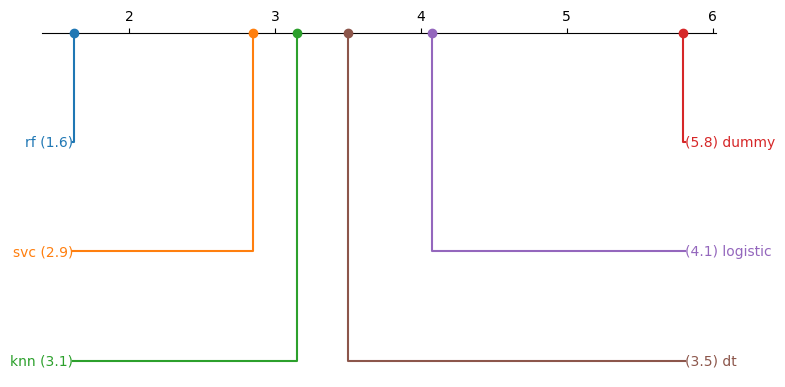

In [16]:
#===SOLUTION===

import matplotlib.pyplot as plt

# Print the critical difference value
print(f"Critical Difference (CD): {crit_value_mean_rank_diff:.4f}")

# Create a dictionary of average ranks
avg_ranks_dict = dict(zip(average_ranks['learner_id'], average_ranks['average_rank_on_task']))

# Create a significance matrix (p-values) from pairwise comparisons
learners = list(avg_ranks_dict.keys())
# All p-values < 0.05 (except diagonal)
sig_matrix = pd.DataFrame(0.04, index=learners, columns=learners) 
for i in range(len(learners)):
    sig_matrix.iloc[i, i] = 1.0

# Create the critical difference diagram
plt.figure(figsize=(8, 4))
sp.critical_difference_diagram(
    ranks=avg_ranks_dict, 
    sig_matrix=sig_matrix,
    crossbar_props=dict(color='None', marker='o'),
    ax=plt.gca(),
    label_fmt_left='{label} ({rank:.2g})',
    label_fmt_right='({rank:.2g}) {label}',
    text_h_margin=0.01
)
plt.tight_layout()
plt.show()
